In [ ]:
!nvidia-smi

In [1]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [2]:
# Pip install method (recommended)

!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.8/112.6 GB disk)


In [3]:
from ultralytics import YOLO

from IPython.display import display, Image

In [7]:
%cd {HOME}
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='/content/WhatsApp Image 2026-02-05 at 7.33.11 PM.jpeg' save=True

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 168 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/WhatsApp Image 2026-02-05 at 7.33.11 PM.jpeg: 640x512 3 persons, 41.2ms
Speed: 3.3ms preprocess, 41.2ms inference, 203.4ms postprocess per image at shape (1, 3, 640, 512)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


/content


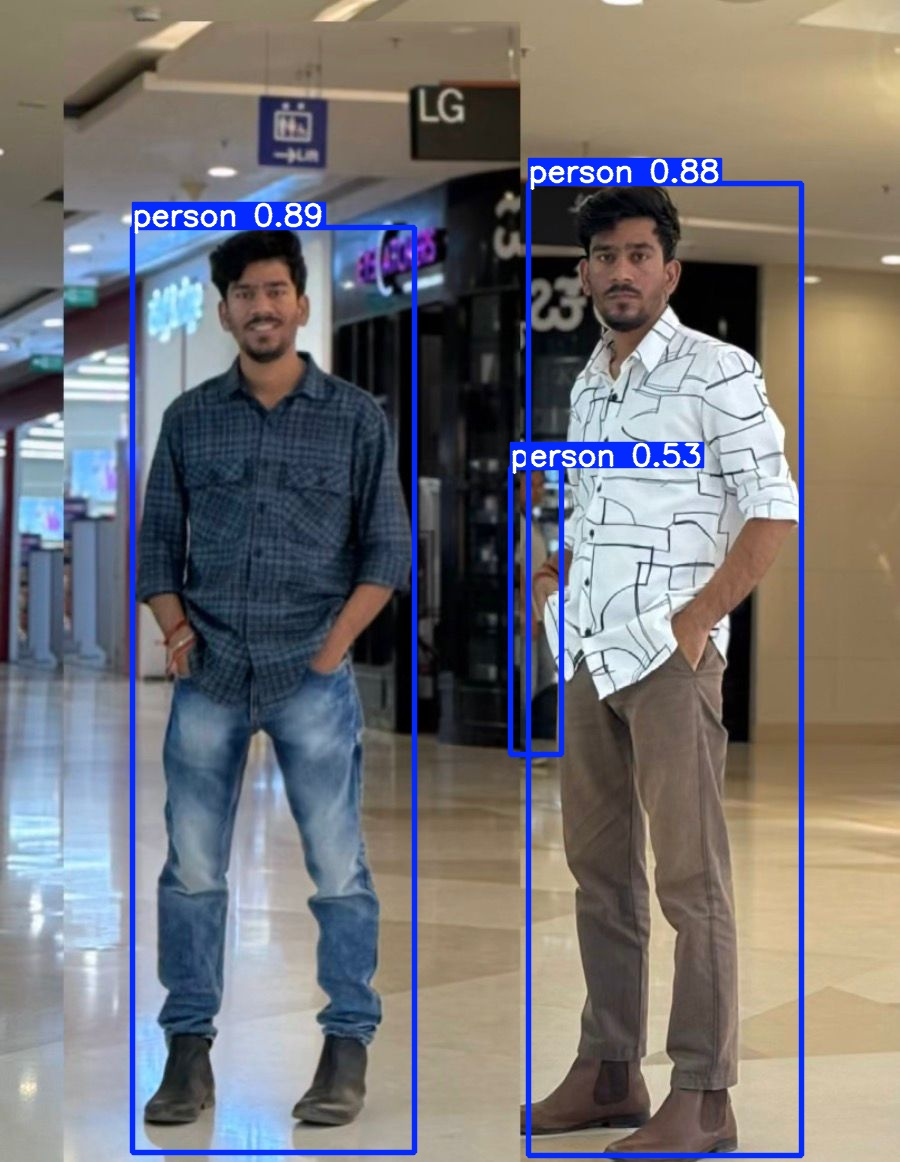

In [8]:
%cd {HOME}
Image(filename='/content/runs/detect/predict/WhatsApp Image 2026-02-05 at 7.33.11 PM.jpeg', height=600)

In [ ]:
!pip install --upgrade numpy matplotlib --force-reinstall


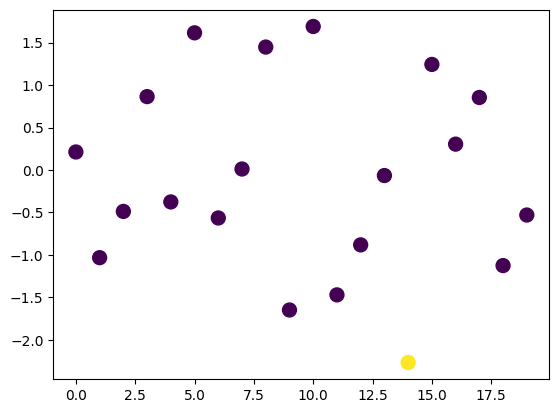

In [2]:
import numpy as np
import matplotlib.pyplot as plt
data = np.random.normal(0, 1, 20)          # normal data
threshold = 2                               # simple rule: >2 is anomaly
plt.scatter(range(len(data)), data, c=(abs(data)>threshold), s=100)  # color anomalies
plt.show()

In [ ]:
from transformers import ViltProcessor,ViltForQuestionAnswering
import requests
from PIL import Image

processor=ViltProcessor.from_pretrained("dandelin/vilt-b32-finetuned-vqa")
model=ViltForQuestionAnswering.from_pretrained("dandelin/vilt-b32-finetuned-vqa")

image = Image.open("/content/Cat_November_2010-1a.jpg")
text = "cat  color"
image

In [1]:

import getpass
import os

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter-Your-GOOGLE_API_KEY")

Enter-Your-GOOGLE_API_KEY··········


In [2]:
!pip install langchain_google_genai
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,

)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.4 MB/s eta 0:00:00


In [3]:
def get_translation(user_text, target_language):
    messages = [
        (
            "system",
            f"You are a helpful assistant that translates English to {target_language}. Translate the user sentence clearly and accurately.",
        ),
        ("human", user_text),
    ]
    ai_msg = llm.invoke(messages)
    return ai_msg.content

In [4]:
print(get_translation("How are you?", "telugu"))


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\nPlease retry in 46.528945004s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url

In [7]:
!pip install groq
import os, getpass
from groq import Groq

# Set API key
if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your GROQ_API_KEY: ")

client = Groq(api_key=os.environ["GROQ_API_KEY"])

# Text and target language
text, lang = "How are you?", "telugu"

# Translate
res = client.chat.completions.create(
    model="openai/gpt-oss-20b",
    messages=[{"role":"system","content":f"Translate English to {lang}."},
              {"role":"user","content":text}]
)
translated = res.choices[0].message.content # Corrected to use .content

# Print
print(translated)
# Removed client.collection("translations").add() as it's not a standard Groq API method

**Telugu translation:**

మీరు ఎలా ఉన్నారు?


In [7]:


import gradio as gr
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch


caption_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
caption_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")


recipe_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
recipe_model = GPT2LMHeadModel.from_pretrained("gpt2")

def image_to_recipe(image):
    image = image.convert("RGB")
    inputs = caption_processor(images=image, return_tensors="pt")
    caption_ids = caption_model.generate(**inputs)
    caption = caption_processor.decode(caption_ids[0], skip_special_tokens=True)


    prompt = f"Write a detailed recipe for: {caption}\n\nIngredients:\n"
    inputs = recipe_tokenizer(prompt, return_tensors="pt")
    output = recipe_model.generate(**inputs, max_length=250, do_sample=True, temperature=0.9)
    recipe = recipe_tokenizer.decode(output[0], skip_special_tokens=True)

    return f"**Caption:** {caption}\n\n **Recipe:**\n{recipe}"

gr.Interface(
    fn=image_to_recipe,
    inputs=gr.Image(type="pil", label="Upload Food Image"),
    outputs=gr.Markdown(),
    title="AI Image to Recipe Generator",
    description="Upload a food image, and the AI will generate a caption + Recipe"
).launch()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7bfa1dd4500612e8b9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
